In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : Handwritten Digit Classification
Algorithm : Long Short-Term Memory (LSTM) – PyTorch
"""

import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [20]:
ds= load_digits()
X = ds.data
y = ds.target

In [21]:
Xtrian, Xtest, ytrain, ytest = train_test_split(X, y, 
                                                test_size=0.2, 
                                                random_state=42)

In [22]:
class DigitsDataset(Dataset):
    def __init__(self, data, targets):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x=  self.data[idx]
        y=  self.targets[idx]
        x= x.view(1, 8,8)  # Reshape to (1, 8, 8)
        return x, y

In [23]:
train_dataset = DigitsDataset(Xtrian, ytrain)
test_dataset = DigitsDataset(Xtest, ytest)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False,drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,drop_last=True)

In [24]:
class LSTM_Classifier(nn.Module):
    def __init__(self, input_size,
                 hidden_size=128, 
                 num_layers=1,
                 bidirectional= False,
                 dropout=0.3,
                 num_classes=10):
        super(LSTM_Classifier, self).__init__()
        
        self.rnn= nn.LSTM(input_size=input_size,
                         hidden_size=hidden_size,
                         batch_first=True,
                         num_layers=num_layers,
                         bidirectional=bidirectional,
                         dropout= dropout if num_layers>1 else 0.0)
        # wx,bx, whh
        D= int(self.rnn.bidirectional)+1
        self.fc= nn.Linear(in_features=hidden_size*D, out_features=num_classes) # wo,bo
        
    def forward(self, x,h0=None,c0=None):
        x= x.squeeze(1)
        num_layers= self.rnn.num_layers
        D= int(self.rnn.bidirectional)+1
        batch_size= x.size(0)
        hidden_size= self.rnn.hidden_size
        if h0==None:
            h_prev= torch.zeros(num_layers*D,batch_size,hidden_size)
            c_prev= torch.zeros(num_layers*D,batch_size,hidden_size)
        else:
            h_prev= h0
            c_prev= c0
        out,(ht,ct)= self.rnn(x,(h_prev,c_prev))
        # many-to-one 
        if self.rnn.bidirectional:
            h_forward= ht[-2] # B*n_hid
            h_backward= ht[-1] #  B*n_hid
            fc_input= torch.cat((h_forward,h_backward),dim=1)
        else: 
            fc_input= ht[-1] 
            # fc_input= out[:,-1,:]
            
        # for many to many we feed Linear with "out"  output= self.fc(out)
        
        output= self.fc(fc_input)
        return output, ht,ct

In [25]:
x,y=train_dataset[0]
num_features= x.shape[2]
criterion = nn.CrossEntropyLoss()

model = LSTM_Classifier(input_size=num_features, 
                        hidden_size=128, 
                        num_layers=2,
                        num_classes=10,
                        bidirectional=True,
                        dropout=0.1)

optimizer = optim.Adam(model.parameters(), 
                       lr=0.001)


In [26]:
num_epochs = 20
h0 = None
c0 = None
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs,ht,ct = model(inputs,h0,c0)
        # h0= ht.detach()
        # c0= ct.detach()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [1/20], Loss: 1.4257
Epoch [2/20], Loss: 0.4162
Epoch [3/20], Loss: 0.1958
Epoch [4/20], Loss: 0.1043
Epoch [5/20], Loss: 0.0635
Epoch [6/20], Loss: 0.0501
Epoch [7/20], Loss: 0.0326
Epoch [8/20], Loss: 0.0303
Epoch [9/20], Loss: 0.0218
Epoch [10/20], Loss: 0.0175
Epoch [11/20], Loss: 0.0354
Epoch [12/20], Loss: 0.0229
Epoch [13/20], Loss: 0.0190
Epoch [14/20], Loss: 0.0137
Epoch [15/20], Loss: 0.0104
Epoch [16/20], Loss: 0.0051
Epoch [17/20], Loss: 0.0057
Epoch [18/20], Loss: 0.0031
Epoch [19/20], Loss: 0.0011
Epoch [20/20], Loss: 0.0009


Test Accuracy: 98.86%


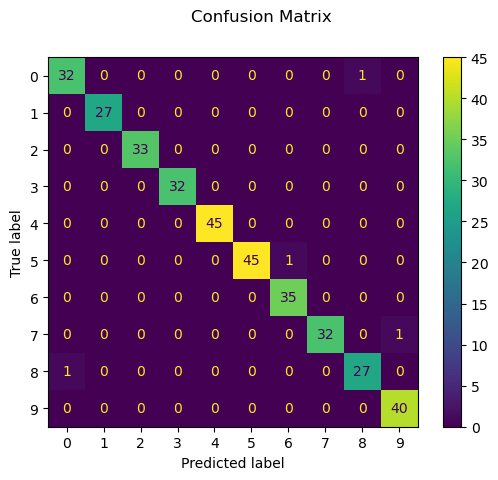

In [27]:
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    ypred_list = []
    ytrue_list = []
    h0,c0 = None,None
    for inputs, labels in test_loader:
        outputs,ht,ct = model(inputs,h0,c0)
        # h0= ht.detach()
        # c0= ct.detach()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        ypred_list.extend(predicted.cpu().numpy())
        ytrue_list.extend(labels.cpu().numpy())
    
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')
# Confusion Matrix

cm = confusion_matrix(ytrue_list, ypred_list)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.figure_.suptitle("Confusion Matrix")
plt.show()
    